In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [117]:
data=pd.read_csv("Admission_Predict.csv")
data.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,1
1,2,324,107,4,4.0,4.5,8.87,1,1
2,3,316,104,3,3.0,3.5,8.00,1,0
3,4,322,110,3,3.5,2.5,8.67,1,1
4,5,314,103,2,2.0,3.0,8.21,0,0


In [118]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         400 non-null    int64  
 1   GRE Score          400 non-null    int64  
 2   TOEFL Score        400 non-null    int64  
 3   University Rating  400 non-null    int64  
 4   SOP                400 non-null    float64
 5   LOR                400 non-null    float64
 6   CGPA               400 non-null    float64
 7   Research           400 non-null    int64  
 8   Chance of Admit    400 non-null    int64  
dtypes: float64(3), int64(6)
memory usage: 28.3 KB


In [119]:
research=data["Research"]

In [120]:
# Split the data for input and output
x=data.drop(["Serial No.","Chance of Admit","Research"],axis=1)
y=data["Chance of Admit"]

In [121]:
x

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA
0,337,118,4,4.5,4.5,9.65
1,324,107,4,4.0,4.5,8.87
2,316,104,3,3.0,3.5,8.00
3,322,110,3,3.5,2.5,8.67
4,314,103,2,2.0,3.0,8.21
...,...,...,...,...,...,...
395,324,110,3,3.5,3.5,9.04
396,325,107,3,3.0,3.5,9.11
397,330,116,4,5.0,4.5,9.45
398,312,103,3,3.5,4.0,8.78


In [122]:
# Scaling is required for some disatnce based algorithm like KNN,naive base,SVM etc..
# logistic regr,decision tree ,i snot required scaling, but scaling does not affect the result too

In [123]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
xnum=sc.fit_transform(x)
xnum=pd.DataFrame(xnum,columns=x.columns)
xnum

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA
0,1.762107,1.746971,0.798829,1.093864,1.167321,1.764818
1,0.627656,-0.067635,0.798829,0.596653,1.167321,0.455151
2,-0.070467,-0.562528,-0.076600,-0.397769,0.052933,-1.005631
3,0.453126,0.427257,-0.076600,0.099442,-1.061454,0.119339
4,-0.244998,-0.727492,-0.952029,-1.392191,-0.504260,-0.653029
...,...,...,...,...,...,...
395,0.627656,0.427257,-0.076600,0.099442,0.052933,0.740592
396,0.714922,-0.067635,-0.076600,-0.397769,0.052933,0.858126
397,1.151249,1.417042,0.798829,1.591075,1.167321,1.429006
398,-0.419528,-0.727492,-0.076600,0.099442,0.610127,0.304036


In [124]:
xfinal=pd.concat([xnum,research],axis=1)
xfinal

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
0,1.762107,1.746971,0.798829,1.093864,1.167321,1.764818,1
1,0.627656,-0.067635,0.798829,0.596653,1.167321,0.455151,1
2,-0.070467,-0.562528,-0.076600,-0.397769,0.052933,-1.005631,1
3,0.453126,0.427257,-0.076600,0.099442,-1.061454,0.119339,1
4,-0.244998,-0.727492,-0.952029,-1.392191,-0.504260,-0.653029,0
...,...,...,...,...,...,...,...
395,0.627656,0.427257,-0.076600,0.099442,0.052933,0.740592,1
396,0.714922,-0.067635,-0.076600,-0.397769,0.052933,0.858126,1
397,1.151249,1.417042,0.798829,1.591075,1.167321,1.429006,1
398,-0.419528,-0.727492,-0.076600,0.099442,0.610127,0.304036,0


In [125]:
y.value_counts(normalize=True)

Chance of Admit
0    0.55
1    0.45
Name: proportion, dtype: float64

In [126]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(xfinal,y,test_size=0.2,random_state=10,stratify=y)

In [127]:
ytrain.value_counts(normalize=True)

Chance of Admit
0    0.55
1    0.45
Name: proportion, dtype: float64

In [128]:
ytest.value_counts(normalize=True)

Chance of Admit
0    0.55
1    0.45
Name: proportion, dtype: float64

In [129]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()

# Train the data
lr.fit(xtrain,ytrain)


LogisticRegression()

In [130]:
# predict the test data
ypredtest=lr.predict(xtest)
ypredtest

array([0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0])

In [131]:
lr.predict_proba(xtest)

array([[7.25425416e-01, 2.74574584e-01],
       [8.95186511e-01, 1.04813489e-01],
       [9.61172794e-01, 3.88272059e-02],
       [2.15252325e-02, 9.78474768e-01],
       [9.68278711e-01, 3.17212886e-02],
       [5.58399094e-01, 4.41600906e-01],
       [2.11324860e-01, 7.88675140e-01],
       [9.90372723e-01, 9.62727716e-03],
       [7.73745102e-01, 2.26254898e-01],
       [9.60796277e-01, 3.92037234e-02],
       [2.00766081e-02, 9.79923392e-01],
       [9.99198134e-01, 8.01865664e-04],
       [3.19761824e-02, 9.68023818e-01],
       [1.12936047e-01, 8.87063953e-01],
       [3.39896714e-03, 9.96601033e-01],
       [9.99079082e-01, 9.20917737e-04],
       [1.94230228e-02, 9.80576977e-01],
       [9.20379761e-01, 7.96202395e-02],
       [4.98362702e-01, 5.01637298e-01],
       [4.76718634e-01, 5.23281366e-01],
       [1.96769311e-01, 8.03230689e-01],
       [6.38985322e-01, 3.61014678e-01],
       [9.96072358e-01, 3.92764246e-03],
       [6.90102372e-01, 3.09897628e-01],
       [9.579213

In [132]:
prob_1=lr.predict_proba(xtest)[:,1]
prob_1

array([2.74574584e-01, 1.04813489e-01, 3.88272059e-02, 9.78474768e-01,
       3.17212886e-02, 4.41600906e-01, 7.88675140e-01, 9.62727716e-03,
       2.26254898e-01, 3.92037234e-02, 9.79923392e-01, 8.01865664e-04,
       9.68023818e-01, 8.87063953e-01, 9.96601033e-01, 9.20917737e-04,
       9.80576977e-01, 7.96202395e-02, 5.01637298e-01, 5.23281366e-01,
       8.03230689e-01, 3.61014678e-01, 3.92764246e-03, 3.09897628e-01,
       4.20786587e-02, 4.14548366e-03, 1.39827037e-02, 9.31261435e-01,
       3.54598728e-01, 3.58287994e-01, 9.48529633e-01, 1.14265546e-01,
       2.60870850e-03, 9.92009853e-01, 8.24194158e-01, 3.68618357e-01,
       9.85800583e-01, 7.65223344e-02, 9.94985285e-01, 8.62301146e-02,
       4.25638440e-01, 1.37275311e-02, 9.19559389e-01, 6.57586969e-01,
       8.50713769e-02, 9.60149046e-05, 1.53055631e-02, 1.54981598e-03,
       9.29245367e-01, 9.08767912e-04, 8.86188524e-01, 4.09161405e-01,
       2.85580512e-02, 2.11330926e-01, 9.77154487e-01, 4.54441926e-02,
      

In [133]:
prob_1=lr.predict_proba(xtest)[:,1]
ans_lr=pd.DataFrame()
ans_lr["Actual"]=ytest
ans_lr["predicted"]=ypredtest
ans_lr["Class1_prob"]=prob_1
ans_lr

,Actual,predicted,Class1_prob
296,1,0,0.274575
265,0,0,0.104813
359,1,0,0.038827
106,1,1,0.978475
180,0,0,0.031721
...,...,...,...
233,0,0,0.011189
56,0,0,0.002756
27,0,0,0.000800
2,0,0,0.072291


In [134]:
from sklearn.metrics import accuracy_score
print("Test Accuracy Score",accuracy_score(ytest,ypredtest))

Test Accuracy Score 0.85


In [135]:
# trainingdata
ypredtrain=lr.predict(xtrain)
print("Training Accuracy Score",accuracy_score(ytrain,ypredtrain))

Training Accuracy Score 0.88125


In [136]:
print("Test Result-------------->")
from sklearn.metrics import confusion_matrix,classification_report,roc_auc_score,roc_curve
cm=confusion_matrix(ytest,ypredtest)
print(cm)
print(classification_report(ytest,ypredtest))

Test Result-------------->
[[40  4]
 [ 8 28]]
              precision    recall  f1-score   support

           0       0.83      0.91      0.87        44
           1       0.88      0.78      0.82        36

    accuracy                           0.85        80
   macro avg       0.85      0.84      0.85        80
weighted avg       0.85      0.85      0.85        80



In [137]:
(0.55*0.91)+(0.45*0.78)

0.8515000000000001

In [138]:
print("Training data----------->")
from sklearn.metrics import confusion_matrix,classification_report
cm1=confusion_matrix(ytrain,ypredtrain)
print(cm1)
print(classification_report(ytrain,ypredtrain))
print("Roc",roc_auc_score(ytrain,ypredtrain))

Training data----------->
[[159  17]
 [ 21 123]]
              precision    recall  f1-score   support

           0       0.88      0.90      0.89       176
           1       0.88      0.85      0.87       144

    accuracy                           0.88       320
   macro avg       0.88      0.88      0.88       320
weighted avg       0.88      0.88      0.88       320

Roc 0.8787878787878788


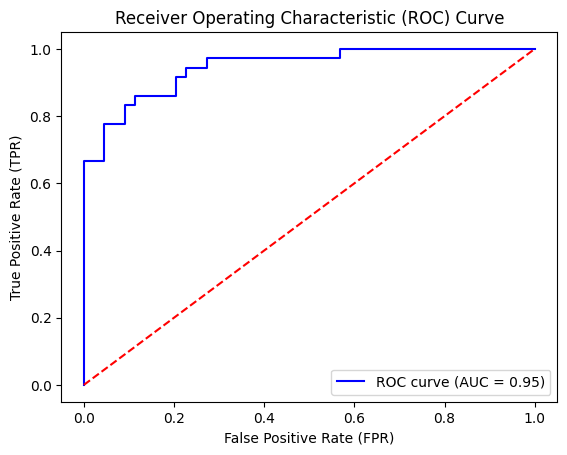

In [139]:
# Calculate the ROC curve
fpr, tpr, thresholds = roc_curve(ytest, prob_1)

# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc_score(ytest, prob_1):.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line for random guessing
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

# KNN classifier

In [140]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=9)
knn.fit(xtrain,ytrain)

KNeighborsClassifier(n_neighbors=9)

In [141]:
ypredknn=knn.predict(xtest)

In [142]:
print("Test Result-------------->")
from sklearn.metrics import confusion_matrix,classification_report,roc_auc_score,roc_curve
cm=confusion_matrix(ytest,ypredknn)
print(cm)
print(classification_report(ytest,ypredknn))

Test Result-------------->
[[41  3]
 [ 7 29]]
              precision    recall  f1-score   support

           0       0.85      0.93      0.89        44
           1       0.91      0.81      0.85        36

    accuracy                           0.88        80
   macro avg       0.88      0.87      0.87        80
weighted avg       0.88      0.88      0.87        80



In [143]:
error_rate = []
#ytest=np.array(ytest)

# Will take some time
for i in range(1,50):
    
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(xtrain,ytrain)
    pred_i = knn.predict(xtest)
    error_rate.append(np.mean(pred_i != ytest))

Text(0, 0.5, 'Error Rate')

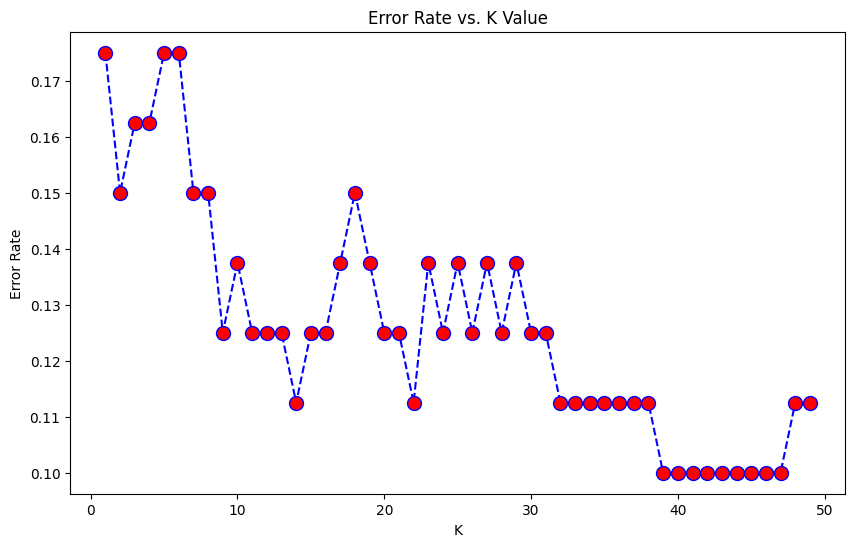

In [144]:
plt.figure(figsize=(10,6))
plt.plot(range(1,50),error_rate,color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')

In [145]:
ypredknntrain=knn.predict(xtrain)


In [146]:
print("Accuracy for train",accuracy_score(ytrain,ypredknntrain))
print("Accuracy for test",accuracy_score(ytest,ypredknn))

Accuracy for train 0.875
Accuracy for test 0.875


In [147]:
# Gridsearchcv-------->hyperpaarmeter tuning

from sklearn.model_selection import GridSearchCV

knn=KNeighborsClassifier()

params={'n_neighbors':np.arange(1,10)}

#kf=KFold(n_splits=3,shuffle=True,random_state=0)

GS=GridSearchCV(knn,params,cv=3,scoring='f1')

GS.fit(xfinal,y)

GridSearchCV(cv=3, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': array([1, 2, 3, 4, 5, 6, 7, 8, 9])},
             scoring='f1')

In [148]:
GS.best_params_

{'n_neighbors': np.int64(9)}

In [149]:
GS.best_score_

np.float64(0.8345954592817623)

In [150]:
knn.fit(xtrain,ytrain)
knn.predict_proba(xtest)

array([[0.8, 0.2],
       [0.8, 0.2],
       [0.8, 0.2],
       [0. , 1. ],
       [1. , 0. ],
       [0.6, 0.4],
       [0.4, 0.6],
       [1. , 0. ],
       [0.8, 0.2],
       [1. , 0. ],
       [0. , 1. ],
       [1. , 0. ],
       [0. , 1. ],
       [0.2, 0.8],
       [0. , 1. ],
       [1. , 0. ],
       [0. , 1. ],
       [0.8, 0.2],
       [0.6, 0.4],
       [0.4, 0.6],
       [0.2, 0.8],
       [0.6, 0.4],
       [1. , 0. ],
       [0.6, 0.4],
       [1. , 0. ],
       [1. , 0. ],
       [1. , 0. ],
       [0. , 1. ],
       [0.6, 0.4],
       [0.6, 0.4],
       [0. , 1. ],
       [1. , 0. ],
       [1. , 0. ],
       [0. , 1. ],
       [0.2, 0.8],
       [0.4, 0.6],
       [0. , 1. ],
       [1. , 0. ],
       [0. , 1. ],
       [0.8, 0.2],
       [0.2, 0.8],
       [1. , 0. ],
       [0. , 1. ],
       [0.6, 0.4],
       [1. , 0. ],
       [1. , 0. ],
       [1. , 0. ],
       [1. , 0. ],
       [0. , 1. ],
       [1. , 0. ],
       [0.4, 0.6],
       [0.6, 0.4],
       [0.8,

In [151]:
prob_1knn=knn.predict_proba(xtest)[:,1]
ans_knn=pd.DataFrame()
ans_knn["Actual"]=ytest
ans_knn["predicted"]=ypredknn
ans_knn["Class1_prob"]=prob_1knn
ans_knn

,Actual,predicted,Class1_prob
296,1,0,0.2
265,0,0,0.2
359,1,0,0.2
106,1,1,1.0
180,0,0,0.0
...,...,...,...
233,0,0,0.0
56,0,0,0.0
27,0,0,0.0
2,0,0,0.4


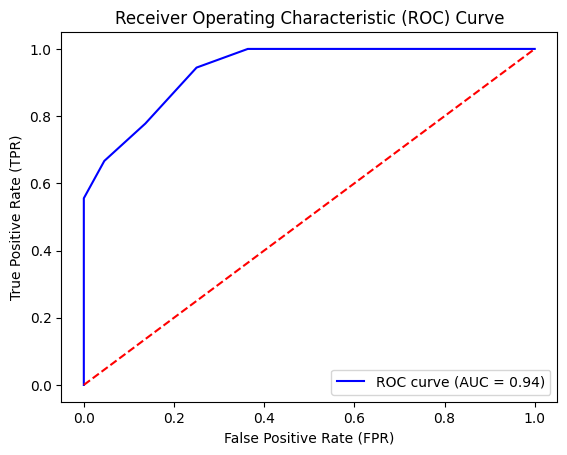

In [152]:
# Calculate the ROC curve
fpr, tpr, thresholds = roc_curve(ytest, prob_1knn)

# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc_score(ytest,prob_1knn):.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line for random guessing
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

# naive bayes Theorm

In [153]:
from sklearn.naive_bayes import GaussianNB
NB=GaussianNB()
NB.fit(xtrain,ytrain)

GaussianNB()

In [154]:
ypredNB=NB.predict(xtest)

In [155]:
prob_Nb_1=NB.predict_proba(xtest)
prob_Nb_1

array([[9.88666938e-01, 1.13330620e-02],
       [9.99963532e-01, 3.64680678e-05],
       [9.99998658e-01, 1.34248718e-06],
       [2.15476084e-06, 9.99997845e-01],
       [9.99992765e-01, 7.23484706e-06],
       [4.94961243e-01, 5.05038757e-01],
       [5.51447948e-03, 9.94485521e-01],
       [9.99999802e-01, 1.97925652e-07],
       [9.94718777e-01, 5.28122300e-03],
       [9.99997737e-01, 2.26254883e-06],
       [2.52629871e-06, 9.99997474e-01],
       [1.00000000e+00, 1.67988954e-12],
       [5.77537667e-06, 9.99994225e-01],
       [1.19145237e-03, 9.98808548e-01],
       [1.26370221e-09, 9.99999999e-01],
       [1.00000000e+00, 4.68737139e-10],
       [8.61489224e-07, 9.99999139e-01],
       [9.99758050e-01, 2.41949712e-04],
       [6.68044807e-01, 3.31955193e-01],
       [4.07429952e-01, 5.92570048e-01],
       [6.58471366e-03, 9.93415286e-01],
       [5.10288247e-01, 4.89711753e-01],
       [9.99999999e-01, 1.10114320e-09],
       [9.81029356e-01, 1.89706441e-02],
       [9.999798

In [156]:
prob_1NB=NB.predict_proba(xtest)[:,1]
ans_NB=pd.DataFrame()
ans_NB["Actual"]=ytest
ans_NB["predicted"]=ypredNB
ans_NB["Class1_prob"]=prob_1NB
ans_NB

,Actual,predicted,Class1_prob
296,1,0,1.133306e-02
265,0,0,3.646807e-05
359,1,0,1.342487e-06
106,1,1,9.999978e-01
180,0,0,7.234847e-06
...,...,...,...
233,0,0,1.043604e-07
56,0,0,2.734154e-08
27,0,0,4.781899e-11
2,0,0,2.425994e-03


In [157]:
print("Test Result for NB-------------->")
from sklearn.metrics import confusion_matrix,classification_report,roc_auc_score,roc_curve
cm=confusion_matrix(ytest,ypredNB)
print(cm)
print(classification_report(ytest,ypredNB))

Test Result for NB-------------->
[[40  4]
 [ 6 30]]
              precision    recall  f1-score   support

           0       0.87      0.91      0.89        44
           1       0.88      0.83      0.86        36

    accuracy                           0.88        80
   macro avg       0.88      0.87      0.87        80
weighted avg       0.88      0.88      0.87        80



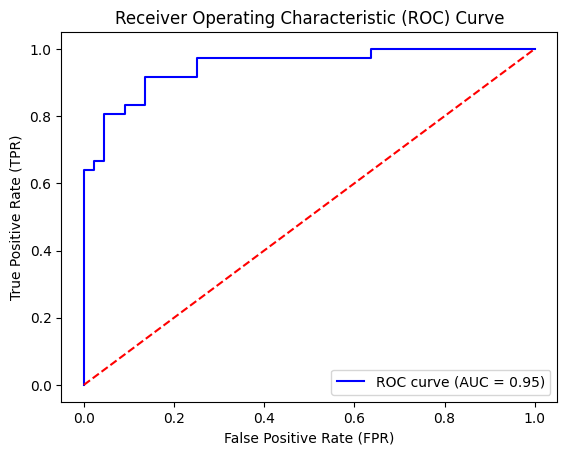

In [158]:
# Calculate the ROC curve
fpr, tpr, thresholds = roc_curve(ytest, prob_1NB)

# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc_score(ytest,prob_1NB):.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line for random guessing
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

# Decison Tree

In [159]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier()
dt.fit(xtrain,ytrain)

DecisionTreeClassifier()

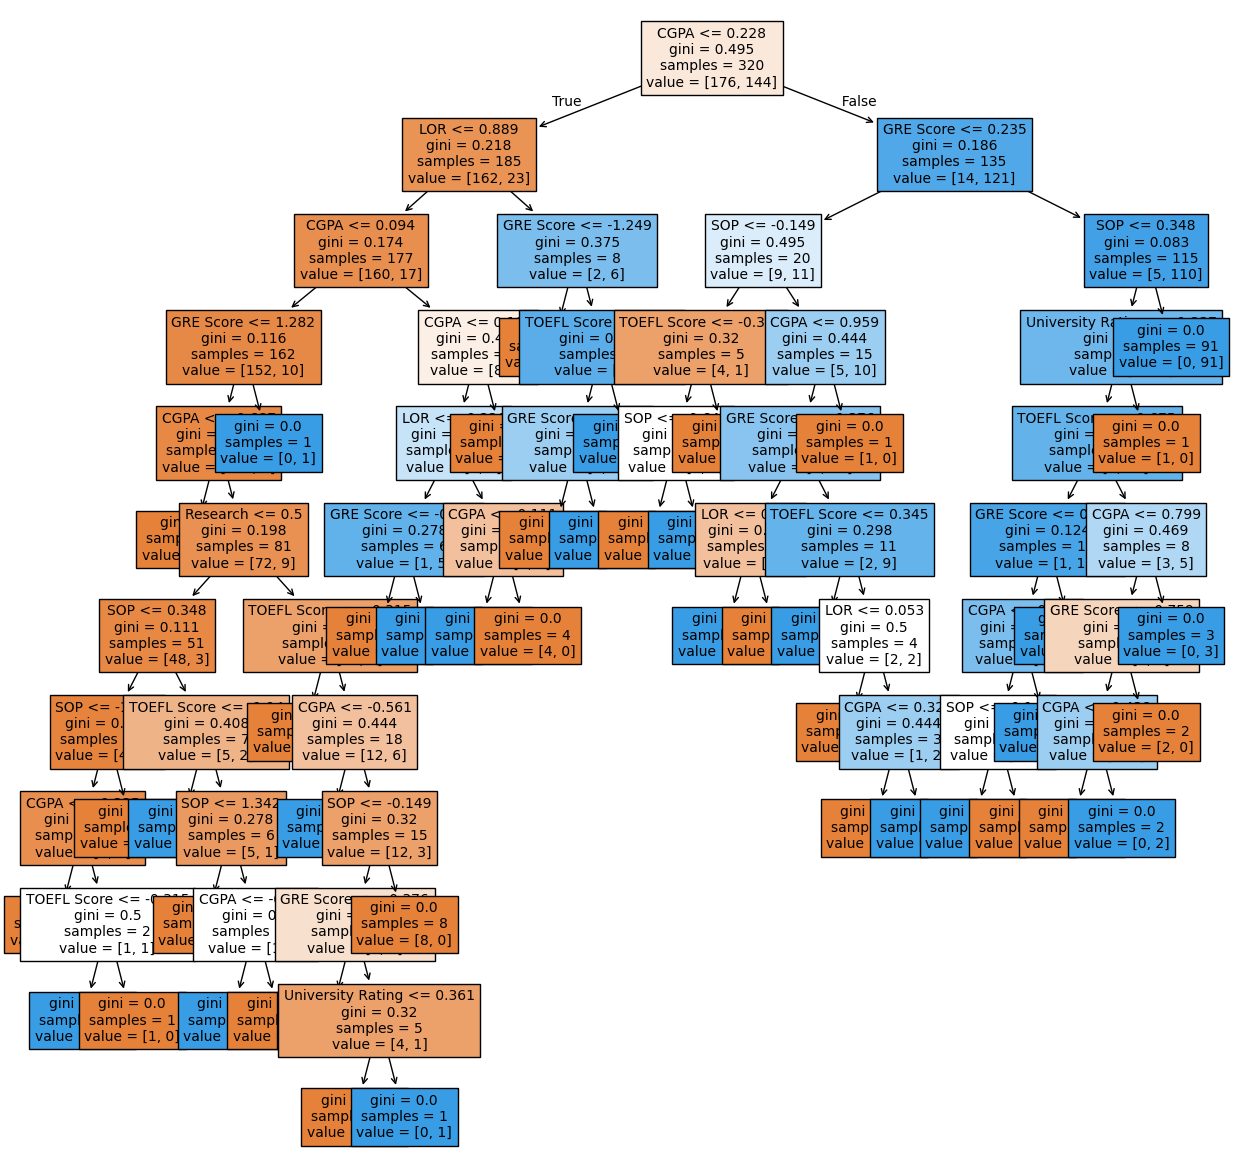

In [160]:
from sklearn import tree
plt.figure(figsize=(15,15))
tree.plot_tree(dt,fontsize=10,feature_names=xtrain.columns,filled=True)
plt.show()

In [161]:
ypred_dt_test=dt.predict(xtest)
ypred_dt_train=dt.predict(xtrain)

In [162]:
print("Training Result for DT-------------->")
from sklearn.metrics import confusion_matrix,classification_report,roc_auc_score,roc_curve
acctr=accuracy_score(ytrain,ypred_dt_train)
print(acctr)


Training Result for DT-------------->
1.0


In [163]:
print(classification_report(ytrain,ypred_dt_train))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       176
           1       1.00      1.00      1.00       144

    accuracy                           1.00       320
   macro avg       1.00      1.00      1.00       320
weighted avg       1.00      1.00      1.00       320



In [164]:
print("Test Result for DT-------------->")
from sklearn.metrics import confusion_matrix,classification_report,roc_auc_score,roc_curve
acct=accuracy_score(ytest,ypred_dt_test)
print(acct)


Test Result for DT-------------->
0.7875


In [165]:
print(classification_report(ytest,ypred_dt_test))

              precision    recall  f1-score   support

           0       0.80      0.82      0.81        44
           1       0.77      0.75      0.76        36

    accuracy                           0.79        80
   macro avg       0.79      0.78      0.78        80
weighted avg       0.79      0.79      0.79        80



In [166]:
# pruning
from sklearn.tree import DecisionTreeClassifier
dt_p=DecisionTreeClassifier(max_depth=5,min_samples_split=15)
dt_p.fit(xtrain,ytrain)

DecisionTreeClassifier(max_depth=5, min_samples_split=15)

In [167]:
ypred_dt_test_p=dt_p.predict(xtest)
ypred_dt_train_p=dt_p.predict(xtrain)

In [168]:
print("Test Result for DT-------------->")
from sklearn.metrics import confusion_matrix,classification_report,roc_auc_score,roc_curve
acct=accuracy_score(ytest,ypred_dt_test_p)
print(acct)

Test Result for DT-------------->
0.7875


In [169]:
print("Training Result for DT-------------->")
from sklearn.metrics import confusion_matrix,classification_report,roc_auc_score,roc_curve
acctr=accuracy_score(ytrain,ypred_dt_train_p)
print(acctr)


Training Result for DT-------------->
0.921875


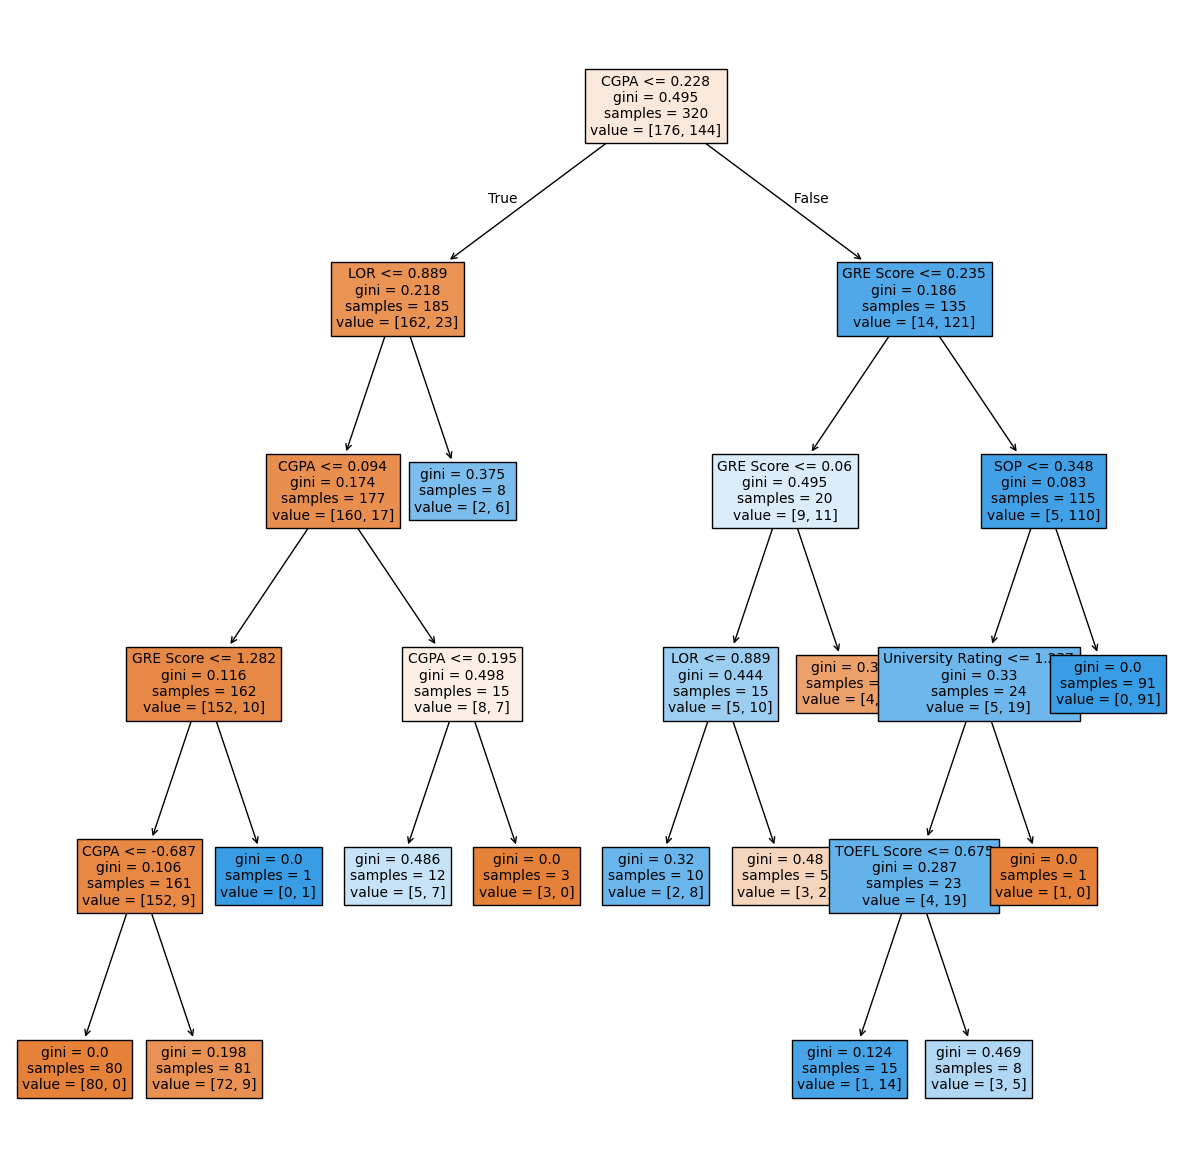

In [170]:
from sklearn import tree
plt.figure(figsize=(15,15))
tree.plot_tree(dt_p,fontsize=10,feature_names=xtrain.columns,filled=True)
plt.show()

In [171]:
#Gridsearch CV
from sklearn.model_selection import GridSearchCV

tuned_paramaters = [{'criterion': ['entropy', 'gini'], 
                     'max_depth': range(2, 10),
                     'min_samples_split': range(2,10),
                     'min_samples_leaf': range(2,10),
                     'max_leaf_nodes': range(3,5)}]

decision_tree_classification = DecisionTreeClassifier(random_state = 10)

tree_grid = GridSearchCV(estimator = decision_tree_classification, 
                         param_grid = tuned_paramaters, 
                         cv = 4,scoring="accuracy")
tree_grid_model = tree_grid.fit(xtrain, ytrain)

#print('Best parameters for decision tree classifier: ', tree_grid_model.best_params_, '\n')

In [172]:
print('Best parameters for decision tree classifier: ', tree_grid_model.best_params_, '\n')

Best parameters for decision tree classifier:  {'criterion': 'gini', 'max_depth': 2, 'max_leaf_nodes': 4, 'min_samples_leaf': 2, 'min_samples_split': 2} 



In [173]:
tuned_decision = DecisionTreeClassifier(criterion = tree_grid_model.best_params_.get('criterion'),
                                  max_depth = tree_grid_model.best_params_.get('max_depth'),
                                  max_leaf_nodes = tree_grid_model.best_params_.get('max_leaf_nodes'),
                                  min_samples_leaf = tree_grid_model.best_params_.get('min_samples_leaf'),
                                  min_samples_split = tree_grid_model.best_params_.get('min_samples_split'),
                                  random_state = 10)
tunedeci=tuned_decision.fit(xtrain,ytrain)

In [174]:
ypred_dt_test_t=tunedeci.predict(xtest)
ypred_dt_train_t=tunedeci.predict(xtrain)

In [175]:
print("Training Result for tuned DT-------------->")
from sklearn.metrics import confusion_matrix,classification_report,roc_auc_score,roc_curve
acctr=accuracy_score(ytrain,ypred_dt_train_t)
print(acctr)

Training Result for tuned DT-------------->
0.896875


In [176]:
print("Test Result for tuned DT-------------->")
from sklearn.metrics import confusion_matrix,classification_report,roc_auc_score,roc_curve
acct=accuracy_score(ytest,ypred_dt_test_t)
print(acct)

Test Result for tuned DT-------------->
0.825


In [177]:
from sklearn.svm import SVC
svm=SVC()
svm.fit(xtrain,ytrain)

SVC()

In [178]:
ypreddt_test_svm=svm.predict(xtest)
ypreddt_train_svm=svm.predict(xtrain)

In [179]:
print("Training accuracy ",accuracy_score(ytrain,ypreddt_train_svm))
print("Test accuarcy",accuracy_score(ytest,ypreddt_test_svm))

Training accuracy  0.89375
Test accuarcy 0.8625
